# HW02: Tokenization

Remember that these homework work as a completion grade. **You can skip one section without losing credit.**

In [1]:
#Import the AG news dataset (same as hw01)
#Download them from here 
#!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 
df["text"] = df["title"] + " " + df["lead"]
df.head()

,label,title,lead,text
0,business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
1,business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
2,business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
3,business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."
4,business,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,"Stocks End Up, But Near Year Lows (Reuters) Re..."


## Preprocess Text

In [2]:
import spacy
dfs = df.sample(50)
nlp = spacy.load('en_core_web_sm')

##TODO use spacy to split the documents in the sampled dataframe (dfs) in sentences and tokens
docs = list(nlp.pipe(dfs["text"]))

# sentences and tokens per document (used in subsequent cells)
sentences = [[sent for sent in doc.sents] for doc in docs]
tokens = [[token for token in doc] for doc in docs]

##TODO print the first sentence of the first document in your sample
first_sent = list(docs[0].sents)[0]
print("First sentence of first document:")
print(first_sent)
print(f"\nTokens: {[token.text for token in first_sent]}")


First sentence of first document:
RBI dy governor Mohan to be finance secy (Reuters) Reuters -

Tokens: ['RBI', 'dy', 'governor', 'Mohan', 'to', 'be', 'finance', 'secy', '(', 'Reuters', ')', 'Reuters', '-']


In [3]:
##TODO create a new column with tokens in lowercase (x.lower()), without punctuation tokens (x.is_punct), stopwords (x.is_stop), and digits (x.is_digit)
def filter_tokens(doc):
    return [token.lower_ for token in doc
            if not token.is_punct and not token.is_stop and not token.is_digit]

dfs = dfs.copy()  # avoid SettingWithCopyWarning
dfs["tokens"] = [filter_tokens(doc) for doc in docs]
print(dfs[["text", "tokens"]].head(3))

##TODO print the tokens (x.lemma_) and the dependency labels (x.dep_) of the first sentence of the first document (doc.sents)
print("\nLemmas and dependency labels for first sentence of first document:")
for token in first_sent:
    print(f"  {token.lemma_:<20} dep: {token.dep_}")


                                                    text  \
73027  RBI dy governor Mohan to be finance secy (Reut...   
36476  N.Korea May Be Preparing Missile Launch-Paper ...   
41018  E-Commerce Attacks on the Rise Symantec recent...   

                                                  tokens  
73027  [rbi, dy, governor, mohan, finance, secy, reut...  
36476  [n.korea, preparing, missile, launch, paper,  ...  
41018  [e, commerce, attacks, rise, symantec, recentl...  

Lemmas and dependency labels for first sentence of first document:
  RBI                  dep: nsubj
  dy                   dep: prep
  governor             dep: compound
  Mohan                dep: pobj
  to                   dep: aux
  be                   dep: ROOT
  finance              dep: compound
  secy                 dep: attr
  (                    dep: punct
  Reuters              dep: nmod
  )                    dep: punct
  Reuters              dep: attr
  -                    dep: punct


### Named Entities

Let's compute the ratio of named entities starting with a capital letter, e.g. if we have "University of Chicago" as a NE, "University" and "Chicago" are capitalized, "of" is not, thus the ratio is 2/3.

In [4]:
ne_total = 0
ne_capital = 0

for doc in docs:
    for ent in doc.ents:
        for token in ent:
            ne_total += 1
            if token.text[0].isupper():
                ne_capital += 1

ratio = ne_capital / ne_total if ne_total > 0 else 0
print(f"Ratio of capitalized tokens within NE spans: {ratio:.4f}  ({ne_capital}/{ne_total})")


Ratio of capitalized tokens within NE spans: 0.6316  (360/570)


In [5]:
total_tokens = 0
cap_non_ne = 0

for doc in docs:
    for token in doc:
        total_tokens += 1
        if token.text[0].isupper() and token.ent_type_ == "":
            cap_non_ne += 1

ratio = cap_non_ne / total_tokens if total_tokens > 0 else 0
print(f"Ratio of capitalized non-NE tokens: {ratio:.4f}  ({cap_non_ne}/{total_tokens})")


Ratio of capitalized non-NE tokens: 0.0852  (195/2289)


In [6]:
total_tokens = 0
cap_non_ne_non_start = 0

for doc in docs:
    for token in doc:
        total_tokens += 1
        if token.text[0].isupper() and token.ent_type_ == "" and not token.is_sent_start:
            cap_non_ne_non_start += 1

ratio = cap_non_ne_non_start / total_tokens if total_tokens > 0 else 0
print(f"Ratio of capitalized non-NE non-sentence-start tokens: {ratio:.4f}  ({cap_non_ne_non_start}/{total_tokens})")


Ratio of capitalized non-NE non-sentence-start tokens: 0.0686  (157/2289)


Give an example of a capitalized token in the data which is neither a named entity nor at the start of a sentence. What could be the reason the token is capitalized (one sentence)?

## Term Frequencies

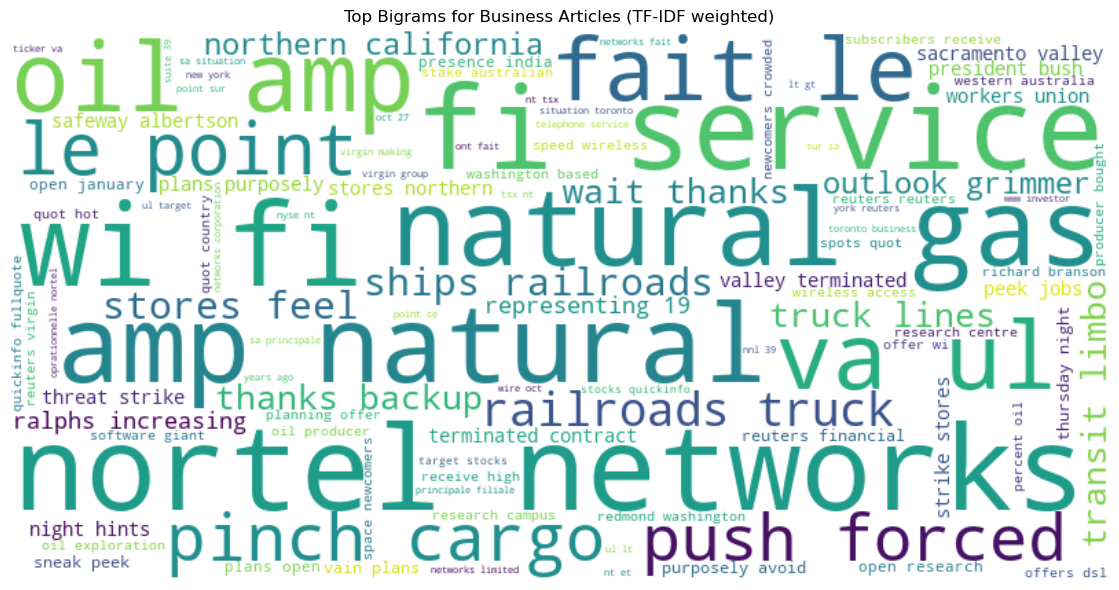

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(min_df=0.01,
                        max_df=0.9,
                        max_features=1000,
                        stop_words='english',
                        use_idf=True,
                        ngram_range=(1,2))

from wordcloud import WordCloud
import matplotlib.pyplot as plt

##TODO using the whole sample, produce a word cloud with bigrams for label == business using tfidf frequencies

# fit on the whole 50-doc sample
tfidf_matrix = tfidf.fit_transform(dfs["text"])
feature_names = tfidf.get_feature_names_out()

# average TF-IDF scores across business documents only
business_mask = (dfs["label"].values == "business")
business_tfidf = tfidf_matrix[business_mask]
mean_scores = business_tfidf.mean(axis=0).A1

# keep only bigrams (terms containing a space)
word_scores = {term: score for term, score in zip(feature_names, mean_scores)
               if " " in term and score > 0}

wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_scores)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Top Bigrams for Business Articles (TF-IDF weighted)")
plt.tight_layout()
plt.show()


## Supervised Feature Selection

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
import numpy as np

##TODO compute the number of words per document (excluding stopwords)
# reuse the filtered tokens column created earlier
word_counts = dfs["tokens"].apply(len).values
print(f"Word counts — min: {word_counts.min()}, max: {word_counts.max()}, mean: {word_counts.mean():.1f}")

X = tfidf_matrix  # TF-IDF from previous cell (non-negative, required by chi2)
y = word_counts
k = 10  # number of top features to show

##TODO get the most predictive features of the number of words per document using first f_classif and then chi2
selector_f = SelectKBest(f_classif, k=k).fit(X, y)
top_f = feature_names[selector_f.get_support()]
scores_f = selector_f.scores_[selector_f.get_support()]
print(f"\nTop {k} features (f_classif):")
for feat, score in sorted(zip(top_f, scores_f), key=lambda x: -x[1]):
    print(f"  {feat:<30} F={score:.2f}")

selector_chi2 = SelectKBest(chi2, k=k).fit(X, y)
top_chi2 = feature_names[selector_chi2.get_support()]
scores_chi2 = selector_chi2.scores_[selector_chi2.get_support()]
print(f"\nTop {k} features (chi2):")
for feat, score in sorted(zip(top_chi2, scores_chi2), key=lambda x: -x[1]):
    print(f"  {feat:<30} χ²={score:.2f}")


Word counts — min: 14, max: 59, mean: 25.7

Top 10 features (f_classif):
  west africa                    F=inf
  wounded                        F=inf
  wounded jabalya                F=inf
  www                            F=inf
  www investor                   F=inf
  year ago                       F=inf
  year end                       F=inf
  year percent                   F=inf
  years ago                      F=inf
  york reuters                   F=inf

Top 10 features (chi2):
  home                           χ²=29.77
  gaza                           χ²=17.02
  militant                       χ²=17.02
  36                             χ²=16.54
  billion                        χ²=16.54
  2004 remote                    χ²=15.03
  chances                        χ²=15.03
  remote                         χ²=15.03
  saddam                         χ²=15.03
  year end                       χ²=14.88


/opt/anaconda3/envs/tad_courses/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Are the results different? What could be a reason for this? 

## Huggingface Tokenizers

In [10]:
# # we use distilbert tokenizer
# !pip install transformers
from transformers import DistilBertTokenizerFast

# let's instantiate a tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

##TODO tokenize the sentences in the sampled dataframe (dfs) using the DistilBertTokenizer
all_tokens = []
for text in dfs["text"]:
    all_tokens.extend(tokenizer.tokenize(text))  # tokenize() skips [CLS]/[SEP] special tokens

##TODO what is the type/token ratio from this tokenizer (number_of_unique_token_types/number_of_tokens)?
total_tokens = len(all_tokens)
unique_types = len(set(all_tokens))
type_token_ratio = unique_types / total_tokens
print(f"Total tokens:       {total_tokens}")
print(f"Unique token types: {unique_types}")
print(f"Type/token ratio:   {type_token_ratio:.4f}")

##TODO what is the amount of subword tokens returned by the huggingface tokenizer? hint: each subword token starts with "##"
subword_tokens = [t for t in all_tokens if t.startswith("##")]
n_subword = len(subword_tokens)
print(f"\nSubword tokens (##): {n_subword}  ({n_subword / total_tokens:.2%} of all tokens)")


Total tokens:       2666
Unique token types: 1141
Type/token ratio:   0.4280

Subword tokens (##): 208  (7.80% of all tokens)


# Parsing

In [11]:
import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 
df["text"] = df["title"] + " " + df["lead"]
df = df.sample(n=10000) # # only use 10K datapoints
df.head()

,label,title,lead,text
66875,sci/tech,New GTA: San Andreas Tr,Rockstar has released a new trailer for Grand ...,New GTA: San Andreas Tr Rockstar has released ...
53456,sport,Domenech names experimental midfield for Ireland,France #39;s coach Raymond Domenech opted for ...,Domenech names experimental midfield for Irela...
38422,world,Nigerian teacher flees Koran row,A Christian teacher goes into hiding in the no...,Nigerian teacher flees Koran row A Christian t...
73101,sci/tech,Sony takes on iPod Mini,Sony has launched two flash memory digital mus...,Sony takes on iPod Mini Sony has launched two ...
103101,business,Global forex volatility underscores China #39;...,SHANGHAI : Foreign exchange markets felt the i...,Global forex volatility underscores China #39;...


In [13]:
import spacy
nlp = spacy.load('en_core_web_sm')

#TODO preprocess the corpus using spacy
docs = list(nlp.pipe(df["text"], batch_size=64))
print(f"Processed {len(docs)} documents")


Processed 10000 documents


### Information Extraction

In [14]:
def extract_subject_verb_pairs(sent):
    subjs = [w for w in sent if w.dep_ == "nsubj"]
    pairs = [(w.lemma_.lower(), w.head.lemma_.lower()) for w in subjs]
    return pairs

##TODO extract the subject-verbs pairs and print the result for the second document
second_doc_pairs = [pair for sent in docs[1].sents for pair in extract_subject_verb_pairs(sent)]
print("Subject-verb pairs in second document:")
print(second_doc_pairs)

from collections import Counter
counter = Counter()

##TODO create a list ranking the most common pairs and print the first 10 items
for doc in docs:
    for sent in doc.sents:
        counter.update(extract_subject_verb_pairs(sent))

print("\n10 most common subject-verb pairs:")
for pair, count in counter.most_common(10):
    print(f"  {pair[0]} -> {pair[1]}: {count}")


Subject-verb pairs in second document:
[('domenech', 'name'), ('he', 'name')]

10 most common subject-verb pairs:
  it -> be: 264
  official -> say: 158
  he -> be: 96
  that -> be: 77
  company -> say: 66
  they -> be: 50
  police -> say: 43
  spokesman -> say: 41
  corp. -> say: 38
  source -> say: 36


In [15]:
##TODO do the same for verbs-object pairs ('dobj')
def extract_verb_object_pairs(sent):
    objs = [w for w in sent if w.dep_ == "dobj"]
    pairs = [(w.head.lemma_.lower(), w.lemma_.lower()) for w in objs]
    return pairs

second_doc_vo_pairs = [pair for sent in docs[1].sents for pair in extract_verb_object_pairs(sent)]
print("Verb-object pairs in second document:")
print(second_doc_vo_pairs)

##TODO create a list ranking the most common pairs and print the first 10 items
vo_counter = Counter()
for doc in docs:
    for sent in doc.sents:
        vo_counter.update(extract_verb_object_pairs(sent))

print("\n10 most common verb-object pairs:")
for pair, count in vo_counter.most_common(10):
    print(f"  {pair[0]} -> {pair[1]}: {count}")


Verb-object pairs in second document:
[('name', 'midfield'), ('name', 'side')]

10 most common verb-object pairs:
  kill -> people: 83
  cut -> job: 36
  pay -> million: 26
  take -> lead: 24
  file -> lawsuit: 23
  call -> what: 22
  raise -> rate: 21
  announce -> plan: 21
  report -> profit: 20
  win -> medal: 19


In [16]:
##TODO do the same for adjectives-nouns pairs ('amod')
def extract_adjective_noun_pairs(sent):
    adjs = [w for w in sent if w.dep_ == "amod"]
    pairs = [(w.lemma_.lower(), w.head.lemma_.lower()) for w in adjs]
    return pairs

second_doc_an_pairs = [pair for sent in docs[1].sents for pair in extract_adjective_noun_pairs(sent)]
print("Adjective-noun pairs in second document:")
print(second_doc_an_pairs)

##TODO create a list ranking the most common pairs and print the first 10 items
an_counter = Counter()
for doc in docs:
    for sent in doc.sents:
        an_counter.update(extract_adjective_noun_pairs(sent))

print("\n10 most common adjective-noun pairs:")
for pair, count in an_counter.most_common(10):
    print(f"  {pair[0]} -> {pair[1]}: {count}")


Adjective-noun pairs in second document:
[('experimental', 'midfield'), ('experimental', 'midfield')]

10 most common adjective-noun pairs:
  third -> quarter: 142
  last -> week: 126
  next -> year: 100
  first -> time: 94
  last -> night: 80
  last -> year: 73
  mobile -> phone: 69
  presidential -> election: 65
  next -> week: 60
  open -> source: 58


### Exploring cross label dependencies

In [17]:
##TODO extract all the subject-verbs and verbs-object pairs for the verb "rise"
rise_sv_pairs = []
rise_vo_pairs = []

for doc in docs:
    for sent in doc.sents:
        rise_sv_pairs.extend([p for p in extract_subject_verb_pairs(sent) if p[1] == "rise"])
        rise_vo_pairs.extend([p for p in extract_verb_object_pairs(sent) if p[0] == "rise"])

print(f"Subject-verb pairs for 'rise' ({len(rise_sv_pairs)} total):")
print(rise_sv_pairs)

print(f"\nVerb-object pairs for 'rise' ({len(rise_vo_pairs)} total):")
print(rise_vo_pairs)


Subject-verb pairs for 'rise' (220 total):
[('profit', 'rise'), ('dollar', 'rise'), ('dollar', 'rise'), ('tech', 'rise'), ('toll', 'rise'), ('stocks', 'rise'), ('earning', 'rise'), ('rose', 'rise'), ('sale', 'rise'), ('choice', 'rise'), ('application', 'rise'), ('profit', 'rise'), ('advances', 'rise'), ('dollar', 'rise'), ('prices', 'rise'), ('price', 'rise'), ('which', 'rise'), ('profit', 'rise'), ('price', 'rise'), ('markets', 'rise'), ('stocks', 'rise'), ('share', 'rise'), ('dow', 'rise'), ('profit', 'rise'), ('profit', 'rise'), ('gdp', 'rise'), ('gain', 'rise'), ('share', 'rise'), ('stock', 'rise'), ('glass', 'rise'), ('stock', 'rise'), ('rises', 'rise'), ('rate', 'rise'), ('rate', 'rise'), ('share', 'rise'), ('stock', 'rise'), ('price', 'rise'), ('calms', 'rise'), ('temper', 'rise'), ('number', 'rise'), ('claims', 'rise'), ('profit', 'rise'), ('profit', 'rise'), ('price', 'rise'), ('earning', 'rise'), ('anger', 'rise'), ('profit', 'rise'), ('profit', 'rise'), ('that', 'rise'), ('s

In [18]:
##TODO for each label create a list ranking the most common subject-verbs pairs and one for the most common verbs-object pairs
from collections import defaultdict

sv_by_label = defaultdict(Counter)
vo_by_label = defaultdict(Counter)

for doc, label in zip(docs, df["label"]):
    for sent in doc.sents:
        sv_by_label[label].update(extract_subject_verb_pairs(sent))
        vo_by_label[label].update(extract_verb_object_pairs(sent))

##TODO print the 10 most common pairs for each of the two lists for the labels "world" and "sci/tech"
for label in ["world", "sci/tech"]:
    print(f"\n=== {label.upper()} ===")

    print("  Top 10 subject-verb pairs:")
    for pair, count in sv_by_label[label].most_common(10):
        print(f"    {pair[0]} -> {pair[1]}: {count}")

    print("  Top 10 verb-object pairs:")
    for pair, count in vo_by_label[label].most_common(10):
        print(f"    {pair[0]} -> {pair[1]}: {count}")



=== WORLD ===
  Top 10 subject-verb pairs:
    official -> say: 117
    it -> be: 56
    police -> say: 39
    that -> kill: 27
    spokesman -> say: 27
    military -> say: 24
    he -> be: 23
    minister -> say: 20
    bomb -> explode: 20
    government -> say: 18
  Top 10 verb-object pairs:
    kill -> people: 78
    withdraw -> troop: 15
    wound -> other: 10
    kill -> militant: 10
    kill -> soldier: 9
    detonate -> bomb: 9
    win -> election: 9
    leave -> people: 9
    injure -> people: 8
    face -> charge: 7

=== SCI/TECH ===
  Top 10 subject-verb pairs:
    it -> be: 67
    that -> be: 31
    company -> say: 28
    that -> allow: 23
    scientist -> say: 23
    they -> be: 18
    official -> say: 18
    that -> use: 15
    post&lt;/b&gt;&lt;/font&gt -> color="#666666"&gt;&lt;b&gt;-the: 14
    corp. -> say: 13
  Top 10 verb-object pairs:
    file -> lawsuit: 18
    launch -> service: 12
    release -> version: 12
    announce -> plan: 10
    launch -> version: 10
   